Importando as bibliotecas necessárias

In [1]:
!pip install lime

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from lime.lime_text import LimeTextExplainer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

Definição do nosso texto ou sentença

In [3]:
corpus = "Na regata ele me mata, me maltrata, me arrabata, que emoção no coração."

In [4]:
tokenizer = tf.keras.preprocessing.text.Tokenizer (char_level=False)
tokenizer.fit_on_texts([corpus])
sequence_data = tokenizer.texts_to_sequences([corpus])[0]
vocab_size = len(tokenizer.word_index) + 1

In [5]:
print(corpus)
print(tokenizer.word_index)

Na regata ele me mata, me maltrata, me arrabata, que emoção no coração.
{'me': 1, 'na': 2, 'regata': 3, 'ele': 4, 'mata': 5, 'maltrata': 6, 'arrabata': 7, 'que': 8, 'emoção': 9, 'no': 10, 'coração': 11}


In [6]:
seq_length = 6
sequences = []
for i in range(seq_length, len(sequence_data)):
  sequences.append(sequence_data[i-seq_length:i+1])

sequences = np.array(sequences)
X, y = sequences[:,:-1], sequences[:,-1]

Modelo de Rede Neural

In [7]:
model = Sequential([
    Embedding(vocab_size, 10, input_length=seq_length),
    LSTM(50, return_sequences=False),
    Dense(vocab_size, activation='softmax')
])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam')
history = model.fit(X, y, epochs=300)

Epoch 1/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - loss: 2.4846
Epoch 2/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - loss: 2.4812
Epoch 3/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - loss: 2.4779
Epoch 4/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - loss: 2.4745
Epoch 5/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - loss: 2.4711
Epoch 6/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - loss: 2.4675
Epoch 7/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step - loss: 2.4638
Epoch 8/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - loss: 2.4600
Epoch 9/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 2.4560
Epoch 10/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - loss: 2.4517
Epoch 11/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - loss: 2.4472
Epoch 12/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 2.4425
Epoch 13/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - loss: 2.4374
Epoch 14/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - loss: 2.4321
Epoch 15/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - loss: 2.4263
Epoch 1

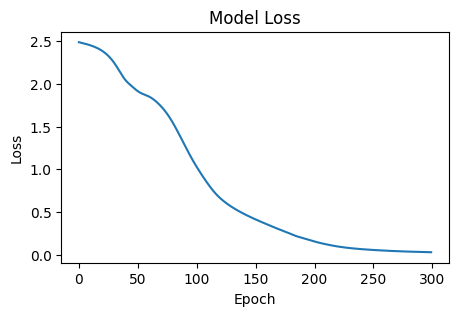

In [9]:
plt.figure(figsize=(5, 3))
plt.plot(history.history['loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.show()

Teste do modelo

In [10]:
#Função para gerar texto
def gerar_texto(modelo, seed_text, next_chars, tokenizer, seq_length):
  result = seed_text
  for _ in range(next_chars):
    encoded = tokenizer.texts_to_sequences([seed_text])[0]
    encoded = np.array(encoded[-seq_length:]).reshape(1, seq_length)
    predicted = np.argmax(modelo.predict(encoded), axis=-1)
    out_char = tokenizer.sequences_to_texts([[predicted[0]]])[0]
    seed_text += out_char
    result += out_char
  return result

seed_text = "Este "
generated = gerar_texto(model, seed_text, 43, tokenizer, seq_length)
print(generated)

ValueError: cannot reshape array of size 1 into shape (1,6)

Explicando a saída do modelo

In [ ]:
def predict_proba(texts):
  sequences = tokenizer.texts_to_sequences(texts)
  padded_sequences = pad_sequences(sequences, maxlen=seq_length, padding='pre')
  predictions = model.predict(padded_sequences)
  return predictions

explainer = LimeTextExplainer(class_names=[str(i) for i in range(vocab_size)])
explanation = explainer.explain_instance(generated, predict_proba, num_features=len(generated))
explanation.show_in_notebook(text=True)

In [ ]:
print(explanation.as_list())